Cell 1: Import Libraries

In [1]:
# Cell 1: Import required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import random
from PIL import Image
from datetime import datetime

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


Cell 2: Define Paths and Configuration

In [2]:
# Cell 2: Define dataset paths
DATASET_PATH = '../dataset'
TRAIN_PATH = os.path.join(DATASET_PATH, '../dataset/Train')
VALIDATION_PATH = os.path.join(DATASET_PATH, '../dataset/Val')
TEST_PATH = os.path.join(DATASET_PATH, '../dataset/Test')

# Check if paths exist
print(f"Dataset path exists: {os.path.exists(DATASET_PATH)}")
print(f"Train path exists: {os.path.exists(TRAIN_PATH)}")
print(f"Validation path exists: {os.path.exists(VALIDATION_PATH)}")
print(f"Test path exists: {os.path.exists(TEST_PATH)}")

Dataset path exists: True
Train path exists: True
Validation path exists: True
Test path exists: True


Cell 3: Get Class Information

In [3]:
# Cell 3: Get all disease classes
if os.path.exists(TRAIN_PATH):
    classes = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
else:
    # If no train folder, use dataset root
    classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])

print(f"📊 Total number of classes: {len(classes)}")
print("\n📋 List of all disease classes:")
for i, class_name in enumerate(classes):
    print(f"   {i+1:2d}. {class_name}")

📊 Total number of classes: 29

📋 List of all disease classes:
    1. Apple - Apple Scab
    2. Apple - Black Rot
    3. Apple - Cedar Apple Rust
    4. Apple - Healthy
    5. Bell Pepper - Bacterial Spot
    6. Bell Pepper - Healthy
    7. Cherry - Healthy
    8. Cherry - Powdery Mildew
    9. Corn (Maize) - Cercospora Leaf Spot
   10. Corn (Maize) - Common Rust
   11. Corn (Maize) - Healthy
   12. Corn (Maize) - Northern Leaf Blight
   13. Grape - Black Rot
   14. Grape - Esca (Black Measles)
   15. Grape - Healthy
   16. Grape - Leaf Blight
   17. Peach - Bacterial Spot
   18. Peach - Healthy
   19. Potato - Early Blight
   20. Potato - Healthy
   21. Potato - Late Blight
   22. Strawberry - Healthy
   23. Strawberry - Leaf Scorch
   24. Tomato - Bacterial Spot
   25. Tomato - Early Blight
   26. Tomato - Healthy
   27. Tomato - Late Blight
   28. Tomato - Septoria Leaf Spot
   29. Tomato - Yellow Leaf Curl Virus


Cell 4: Count Images per Class

In [4]:
# Cell 4: Count images in each class
def count_images_in_class(class_path):
    """Count images in a class directory"""
    if not os.path.exists(class_path):
        return 0
    return len([f for f in os.listdir(class_path) 
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))])

# Use training path or dataset root
source_path = TRAIN_PATH if os.path.exists(TRAIN_PATH) else DATASET_PATH

image_counts = {}
for class_name in classes:
    class_path = os.path.join(source_path, class_name)
    image_counts[class_name] = count_images_in_class(class_path)

# Display counts
print("📊 Images per class:")
print("-" * 50)
for class_name, count in image_counts.items():
    print(f"   {class_name[:35]:35s}: {count:5d} images")

total_images = sum(image_counts.values())
print("-" * 50)
print(f"   {'TOTAL':35s}: {total_images:5d} images")

📊 Images per class:
--------------------------------------------------
   Apple - Apple Scab                 :  2016 images
   Apple - Black Rot                  :  1987 images
   Apple - Cedar Apple Rust           :  1760 images
   Apple - Healthy                    :  2008 images
   Bell Pepper - Bacterial Spot       :  1913 images
   Bell Pepper - Healthy              :  1988 images
   Cherry - Healthy                   :  1826 images
   Cherry - Powdery Mildew            :  1683 images
   Corn (Maize) - Cercospora Leaf Spot:  1642 images
   Corn (Maize) - Common Rust         :  1907 images
   Corn (Maize) - Healthy             :  1859 images
   Corn (Maize) - Northern Leaf Blight:  1908 images
   Grape - Black Rot                  :  1888 images
   Grape - Esca (Black Measles)       :  1920 images
   Grape - Healthy                    :  1692 images
   Grape - Leaf Blight                :  1722 images
   Peach - Bacterial Spot             :  1838 images
   Peach - Healthy          

Cell 5: Visualize Class Distribution

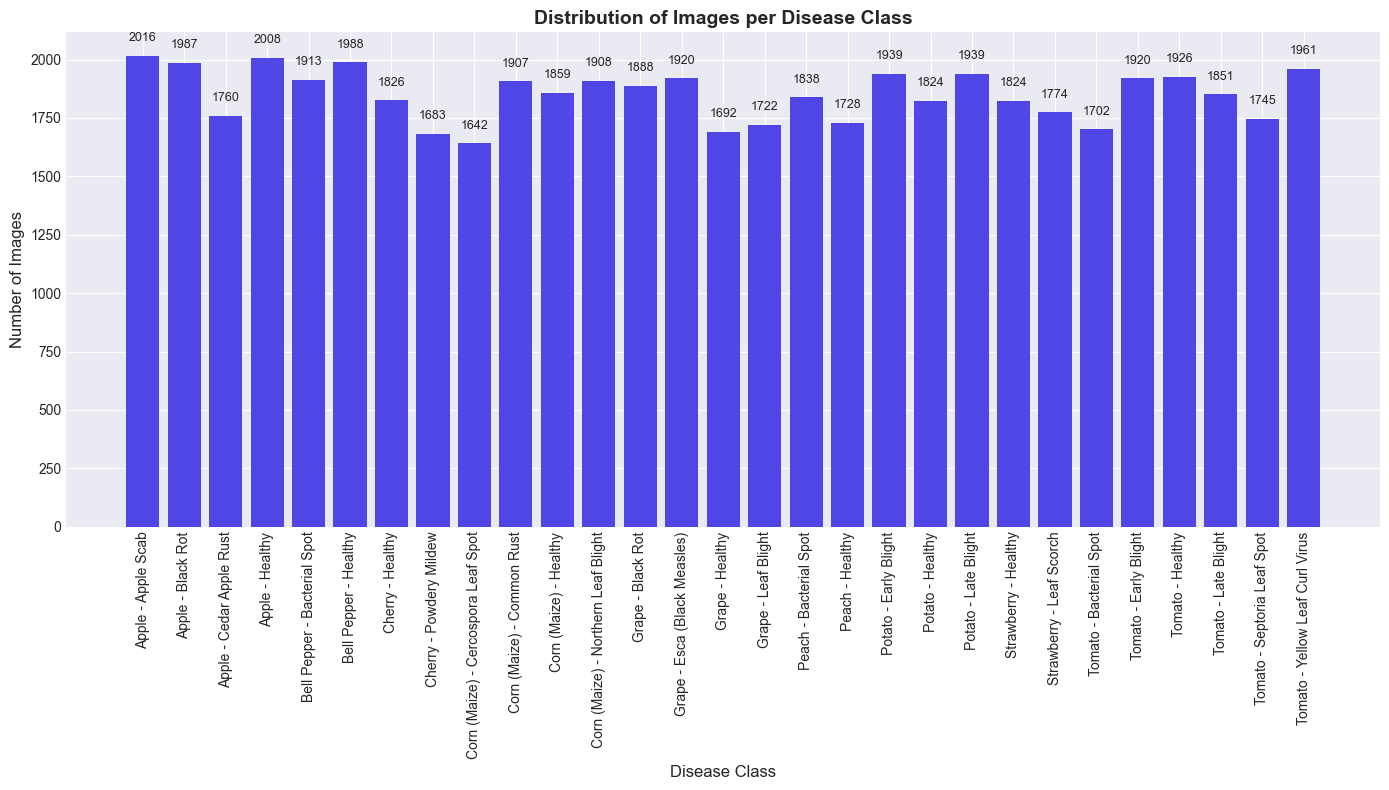

In [5]:
# Cell 5: Bar chart of class distribution
plt.figure(figsize=(14, 8))

# Create bar chart
bars = plt.bar(image_counts.keys(), image_counts.values(), color='#4F46E5')
plt.xticks(rotation=90, fontsize=10)
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Disease Class', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, count in zip(bars, image_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Cell 6: Class Distribution Statistics

📊 Class Distribution Statistics:
   Total Images: 53690
   Number of Classes: 29
   Average Images per Class: 1851
   Minimum Images in a Class: 1642
   Maximum Images in a Class: 2016
   Standard Deviation: 105

📊 Class Imbalance Analysis:
   Classes with >= 1000 images: 29/29
   Classes with < 500 images: 0
   Classes with < 100 images: 0


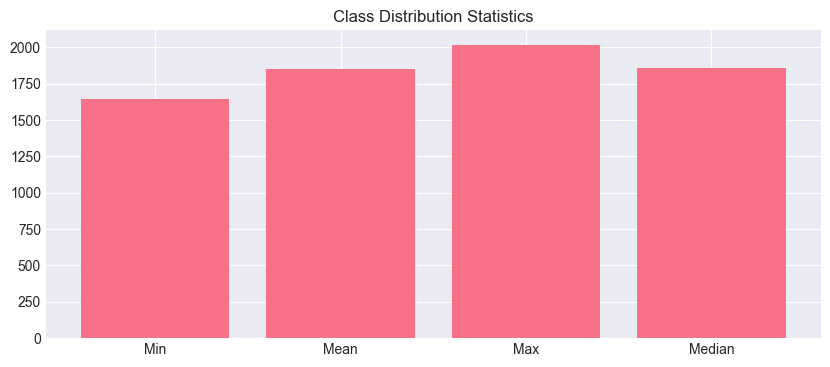

In [6]:
# Cell 6: Statistical analysis of class distribution
counts = list(image_counts.values())
print("📊 Class Distribution Statistics:")
print("="*40)
print(f"   Total Images: {sum(counts)}")
print(f"   Number of Classes: {len(counts)}")
print(f"   Average Images per Class: {sum(counts)/len(counts):.0f}")
print(f"   Minimum Images in a Class: {min(counts)}")
print(f"   Maximum Images in a Class: {max(counts)}")
print(f"   Standard Deviation: {np.std(counts):.0f}")

# Check for class imbalance
print("\n📊 Class Imbalance Analysis:")
print("="*40)
balanced_classes = sum(1 for c in counts if c >= 1000)
print(f"   Classes with >= 1000 images: {balanced_classes}/{len(counts)}")
print(f"   Classes with < 500 images: {sum(1 for c in counts if c < 500)}")
print(f"   Classes with < 100 images: {sum(1 for c in counts if c < 100)}")

plt.figure(figsize=(10, 4))
plt.bar(['Min', 'Mean', 'Max', 'Median'], 
        [min(counts), np.mean(counts), max(counts), np.median(counts)])
plt.title('Class Distribution Statistics')
plt.show()

Cell 7: Crop-wise Disease Distribution

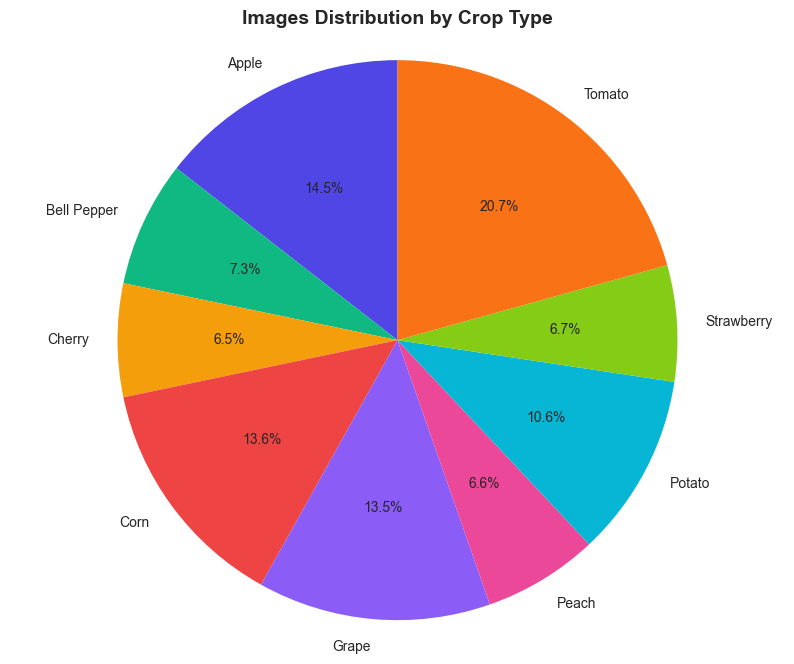


📊 Images per crop:
   Tomato         :  11105 images (20.7%)
   Apple          :   7771 images (14.5%)
   Corn           :   7316 images (13.6%)
   Grape          :   7222 images (13.5%)
   Potato         :   5702 images (10.6%)
   Bell Pepper    :   3901 images (7.3%)
   Strawberry     :   3598 images (6.7%)
   Peach          :   3566 images (6.6%)
   Cherry         :   3509 images (6.5%)


In [7]:
# Cell 7: Group diseases by crop
crop_groups = {
    'Apple': ['Apple', 'Apple_scab', 'Black_rot', 'Cedar_apple_rust'],
    'Bell Pepper': ['Pepper', 'bell'],
    'Cherry': ['Cherry'],
    'Corn': ['Corn', 'maize'],
    'Grape': ['Grape'],
    'Peach': ['Peach'],
    'Potato': ['Potato'],
    'Strawberry': ['Strawberry'],
    'Tomato': ['Tomato']
}

crop_counts = {}
for class_name, count in image_counts.items():
    assigned = False
    for crop, keywords in crop_groups.items():
        if any(keyword.lower() in class_name.lower() for keyword in keywords):
            crop_counts[crop] = crop_counts.get(crop, 0) + count
            assigned = True
            break
    if not assigned:
        crop_counts['Other'] = crop_counts.get('Other', 0) + count

# Create pie chart
plt.figure(figsize=(10, 8))
colors = ['#4F46E5', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899', '#06B6D4', '#84CC16', '#F97316']
plt.pie(crop_counts.values(), labels=crop_counts.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Images Distribution by Crop Type', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

print("\n📊 Images per crop:")
for crop, count in sorted(crop_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   {crop:15s}: {count:6d} images ({count/total_images*100:.1f}%)")

Cell 8: Display Sample Images

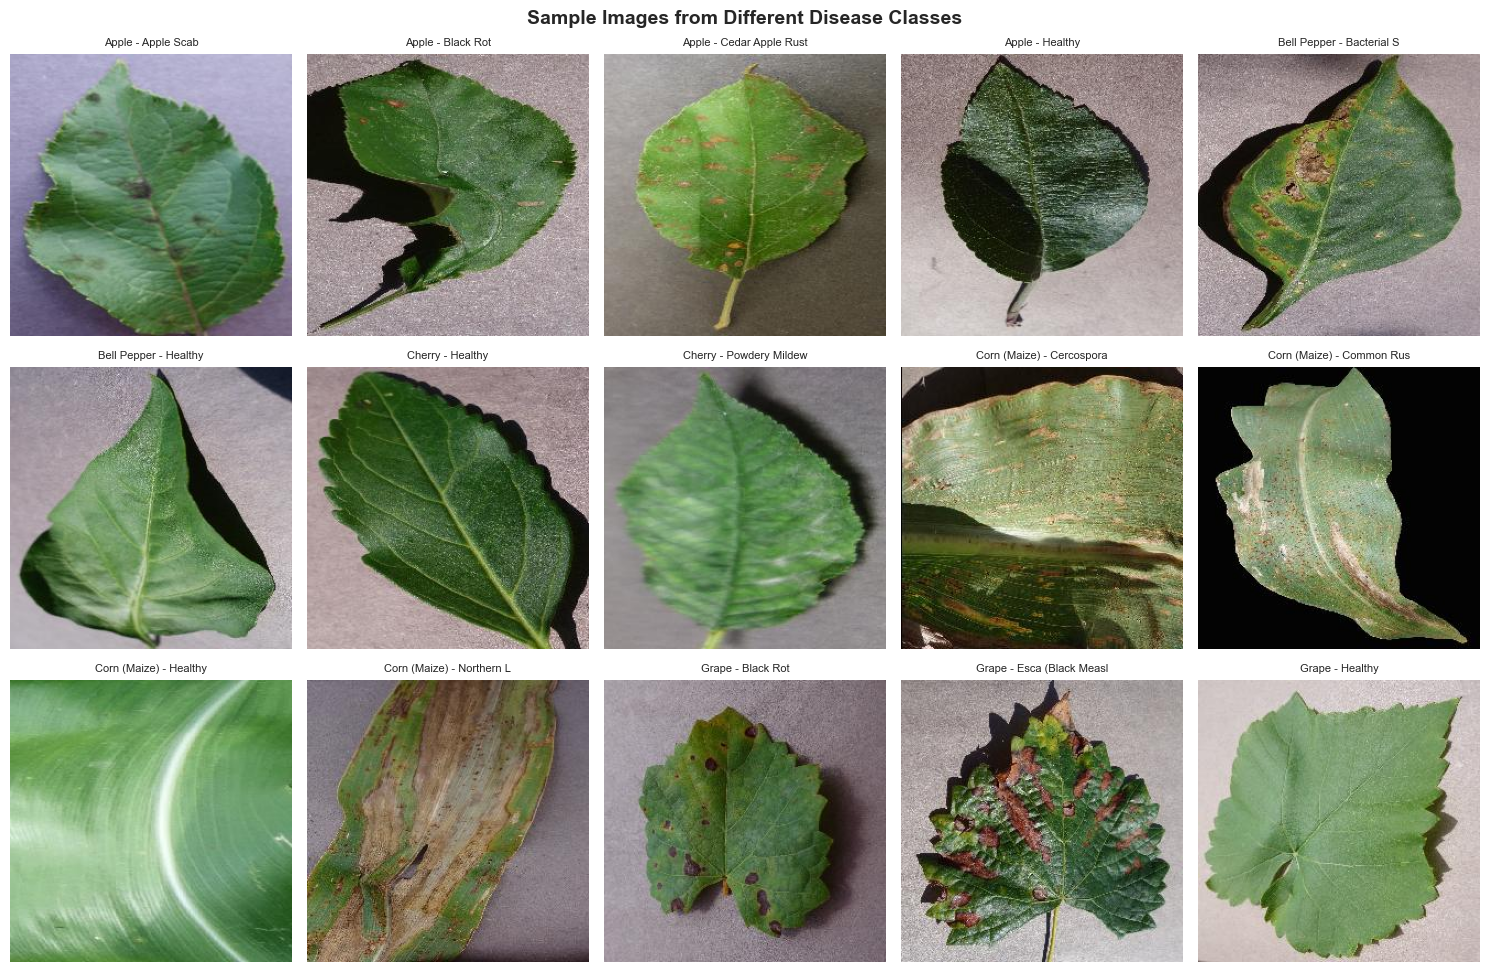

In [8]:
# Cell 8: Display sample images from each class
def load_sample_images(num_samples=5):
    """Load sample images from each class"""
    samples = {}
    for class_name in list(classes)[:15]:  # Limit to first 15 classes
        class_path = os.path.join(source_path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if images:
                img_path = os.path.join(class_path, images[0])
                img = cv2.imread(img_path)
                if img is not None:
                    samples[class_name] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return samples

samples = load_sample_images()

# Display samples in a grid
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
fig.suptitle('Sample Images from Different Disease Classes', fontsize=14, fontweight='bold')

for idx, (class_name, img) in enumerate(list(samples.items())[:15]):
    row = idx // 5
    col = idx % 5
    axes[row, col].imshow(img)
    axes[row, col].set_title(class_name[:25], fontsize=8)
    axes[row, col].axis('off')

# Hide empty subplots
for idx in range(len(samples), 15):
    row = idx // 5
    col = idx % 5
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Cell 9: Image Size Analysis

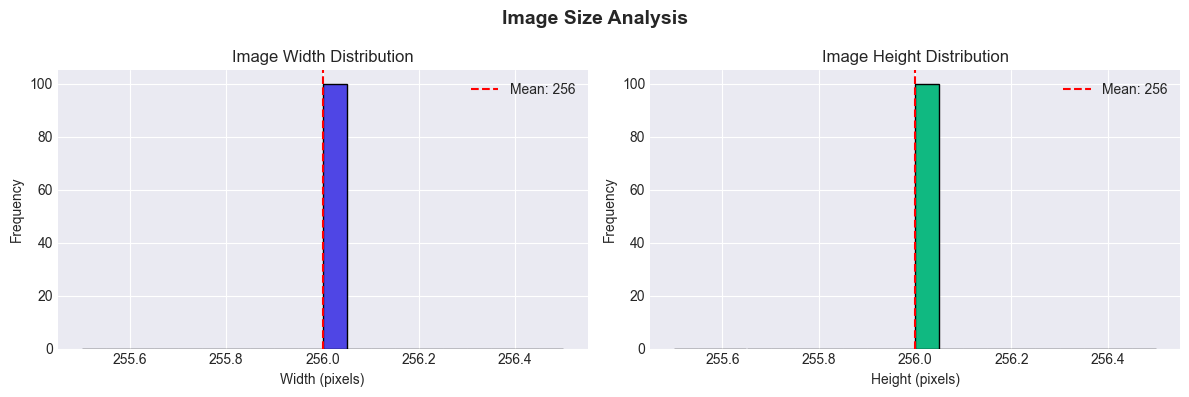


📊 Image Size Statistics:
   Average Width: 256px
   Average Height: 256px
   Min Width: 256px, Max Width: 256px
   Min Height: 256px, Max Height: 256px


In [9]:
# Cell 9: Analyze image dimensions
def analyze_image_sizes(num_samples=100):
    """Analyze image dimensions from random samples"""
    widths = []
    heights = []
    
    all_images = []
    for class_name in classes:
        class_path = os.path.join(source_path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            all_images.extend([os.path.join(class_path, img) for img in images[:5]])  # Limit per class
    
    # Random sample
    sample_images = random.sample(all_images, min(num_samples, len(all_images)))
    
    for img_path in sample_images:
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)
    
    return widths, heights

widths, heights = analyze_image_sizes()

# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(widths, bins=20, color='#4F46E5', edgecolor='black')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')
ax1.set_title('Image Width Distribution')
ax1.axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
ax1.legend()

ax2.hist(heights, bins=20, color='#10B981', edgecolor='black')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')
ax2.set_title('Image Height Distribution')
ax2.axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
ax2.legend()

plt.suptitle('Image Size Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Image Size Statistics:")
print(f"   Average Width: {np.mean(widths):.0f}px")
print(f"   Average Height: {np.mean(heights):.0f}px")
print(f"   Min Width: {min(widths)}px, Max Width: {max(widths)}px")
print(f"   Min Height: {min(heights)}px, Max Height: {max(heights)}px")

Cell 10: Check for Corrupted Images

In [10]:
# Cell 10: Check for corrupted images
def check_corrupted_images(class_path):
    """Check for corrupted images in a directory"""
    corrupted = []
    if not os.path.exists(class_path):
        return corrupted
    
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                img.verify()  # Verify image integrity
            except Exception as e:
                corrupted.append(img_file)
    return corrupted

print("🔍 Checking for corrupted images...")
print("-" * 50)

corrupted_images = {}
for class_name in classes:
    class_path = os.path.join(source_path, class_name)
    corrupted = check_corrupted_images(class_path)
    if corrupted:
        corrupted_images[class_name] = corrupted
        print(f"⚠️ {class_name}: {len(corrupted)} corrupted images found")

if not corrupted_images:
    print("✅ No corrupted images found!")
else:
    print(f"\n📊 Total corrupted images: {sum(len(v) for v in corrupted_images.values())}")

🔍 Checking for corrupted images...
--------------------------------------------------
✅ No corrupted images found!


Cell 11: Class Name Analysis

In [11]:
# Cell 11: Analyze class name patterns
print("📊 Class Name Analysis:")
print("="*50)

healthy_classes = [c for c in classes if 'healthy' in c.lower()]
disease_classes = [c for c in classes if 'healthy' not in c.lower()]

print(f"Healthy classes: {len(healthy_classes)}")
for c in healthy_classes:
    print(f"   - {c}")

print(f"\nDisease classes: {len(disease_classes)}")
for c in disease_classes[:10]:
    print(f"   - {c}")
if len(disease_classes) > 10:
    print(f"   ... and {len(disease_classes)-10} more")

# Check for class name consistency
print("\n📊 Class Name Patterns:")
prefixes = {}
for c in classes:
    prefix = c.split('___')[0] if '___' in c else c.split('-')[0]
    prefixes[prefix] = prefixes.get(prefix, 0) + 1

for prefix, count in sorted(prefixes.items()):
    print(f"   {prefix}: {count} classes")

📊 Class Name Analysis:
Healthy classes: 9
   - Apple - Healthy
   - Bell Pepper - Healthy
   - Cherry - Healthy
   - Corn (Maize) - Healthy
   - Grape - Healthy
   - Peach - Healthy
   - Potato - Healthy
   - Strawberry - Healthy
   - Tomato - Healthy

Disease classes: 20
   - Apple - Apple Scab
   - Apple - Black Rot
   - Apple - Cedar Apple Rust
   - Bell Pepper - Bacterial Spot
   - Cherry - Powdery Mildew
   - Corn (Maize) - Cercospora Leaf Spot
   - Corn (Maize) - Common Rust
   - Corn (Maize) - Northern Leaf Blight
   - Grape - Black Rot
   - Grape - Esca (Black Measles)
   ... and 10 more

📊 Class Name Patterns:
   Apple : 4 classes
   Bell Pepper : 2 classes
   Cherry : 2 classes
   Corn (Maize) : 4 classes
   Grape : 4 classes
   Peach : 2 classes
   Potato : 3 classes
   Strawberry : 2 classes
   Tomato : 6 classes


Cell 12: Summary Report

In [12]:
# Cell 12: Generate exploration summary
print("="*60)
print("📊 DATA EXPLORATION SUMMARY REPORT")
print("="*60)

print(f"\n📁 Dataset Location: {os.path.abspath(source_path)}")
print(f"📊 Total Classes: {len(classes)}")
print(f"🖼️ Total Images: {total_images}")
print(f"📈 Average Images/Class: {total_images/len(classes):.0f}")

print(f"\n📊 Class Distribution:")
print(f"   Most images: {max(image_counts.values())} ({max(image_counts, key=image_counts.get)})")
print(f"   Least images: {min(image_counts.values())} ({min(image_counts, key=image_counts.get)})")
print(f"   Classes with >1000 images: {sum(1 for c in image_counts.values() if c > 1000)}")
print(f"   Classes with <500 images: {sum(1 for c in image_counts.values() if c < 500)}")

print(f"\n📊 Image Statistics:")
if widths:
    print(f"   Average Size: {np.mean(widths):.0f} x {np.mean(heights):.0f} pixels")
    print(f"   Size Range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")

print(f"\n📊 Data Split Recommendation:")
print(f"   Training: {int(total_images * 0.7)} images")
print(f"   Validation: {int(total_images * 0.2)} images")
print(f"   Test: {int(total_images * 0.1)} images")

print("\n✅ Data exploration completed successfully!")

📊 DATA EXPLORATION SUMMARY REPORT

📁 Dataset Location: d:\farmintel_ai\backend\dataset\Train
📊 Total Classes: 29
🖼️ Total Images: 53690
📈 Average Images/Class: 1851

📊 Class Distribution:
   Most images: 2016 (Apple - Apple Scab)
   Least images: 1642 (Corn (Maize) - Cercospora Leaf Spot)
   Classes with >1000 images: 29
   Classes with <500 images: 0

📊 Image Statistics:
   Average Size: 256 x 256 pixels
   Size Range: 256x256 to 256x256

📊 Data Split Recommendation:
   Training: 37583 images
   Validation: 10738 images
   Test: 5369 images

✅ Data exploration completed successfully!


Cell 13: Save Exploration Results

In [13]:
# Cell 13: Save exploration results to JSON
exploration_results = {
    'total_classes': len(classes),
    'total_images': total_images,
    'class_distribution': image_counts,
    'class_list': classes,
    'healthy_classes': healthy_classes,
    'disease_classes': disease_classes,
    'average_images_per_class': total_images/len(classes),
    'exploration_date': str(datetime.now())
}

# Save to file
with open('data_exploration_results.json', 'w') as f:
    json.dump(exploration_results, f, indent=2)

print("✅ Exploration results saved to 'data_exploration_results.json'")

✅ Exploration results saved to 'data_exploration_results.json'
